# Cross-system comparison (GWT)

Sanity check: does the ordinal DCM differentiate {Human, Chicken, LLMs, ELIZA} under GWT?

All four systems share the same Beta(1, 5) stance prior and the same tree structure. The only input that differs is the expert ratings at the indicator leaves. If the model can rank systems in the expected order (Human >> Chicken > LLMs > ELIZA), the relative-comparison use case holds even if the absolute posteriors are prior-dependent.

Note: Human and ELIZA have only 1 expert (Rater_B, 50 obs). Chicken has 2 different experts (Hayley, Rater_E, 93 obs). LLMs have 4 experts (186 obs). Each system is fit independently.

In [ ]:
import os, sys, warnings, time

os.environ["PYTENSOR_FLAGS"] = f"compiledir=/tmp/pytensor_cache_nb10_{os.getpid()}"
sys.path.insert(0, "..")
os.chdir(os.path.join(os.path.dirname(os.path.abspath("."))))
warnings.filterwarnings("ignore", message="Loop fusion failed")

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

from dcm_model import ModelConfig, load_data, fit_stance

plt.rcParams.update(
    {"figure.dpi": 120, "font.size": 10, "figure.constrained_layout.use": True}
)

In [ ]:
STANCE = "Global Workspace Theory"
SYSTEMS = ["Human", "Chicken", "2024 Leading Chat LLMs", "ELIZA"]

cfg = ModelConfig(NUM_SAMPLES=2000, NUM_TUNE=500, NUM_CHAINS=4, TARGET_ACCEPT=0.9)
all_data = load_data(cfg)
stance_data = next(s for s in all_data if s["name"] == STANCE)

results = {}
for system in SYSTEMS:
    print(f"\n{'=' * 30} {system} {'=' * 30}")
    t0 = time.time()
    idata, builder, proc = fit_stance(stance_data, cfg, system=system)
    stance_vn = builder.node_to_varname[STANCE]
    draws = idata.posterior[f"{stance_vn}_bern"].values.flatten()
    n_obs = sum(len(v) for v in proc.observations.values())
    results[system] = {
        "idata": idata,
        "builder": builder,
        "processor": proc,
        "draws": draws,
        "n_obs": n_obs,
        "n_experts": len(proc.expert_names),
    }
    print(
        f"  P(C=1) = {draws.mean():.3f}  94% CI = [{np.percentile(draws, 3):.3f}, {np.percentile(draws, 97):.3f}]"
    )
    print(
        f"  n_obs={n_obs}  n_experts={len(proc.expert_names)}  elapsed={time.time() - t0:.0f}s"
    )


============================== Human ==============================


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somatotopic_neural_maps_beta_abs, has_retinotopic_neural_maps_b

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 191 seconds.
There were 121 divergences after tuning. Increase `target_accept` or reparameterize.


  P(C=1) = 0.179  94% CI = [0.007, 0.527]
  n_obs=50  n_experts=1  elapsed=433s

============================== Chicken ==============================


...

  P(C=1) = 0.144  94% CI = [0.004, 0.467]
  n_obs=186  n_experts=4  elapsed=374s

============================== ELIZA ==============================


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somatotopic_neural_maps_beta_abs, has_retinotopic_neural_maps_b

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 75 seconds.


  P(C=1) = 0.166  94% CI = [0.006, 0.510]
  n_obs=50  n_experts=1  elapsed=219s


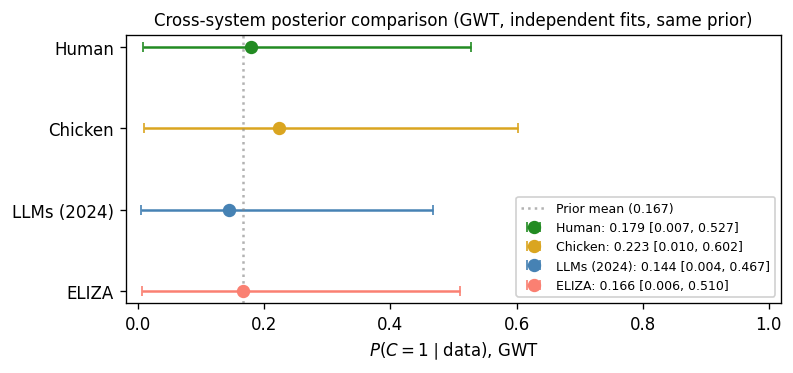


System                      P(C=1)              94% CI  n_obs  n_exp  shift from prior
-------------------------------------------------------------------------------------
Human                        0.179  [0.007, 0.527]     50      1            +0.012
Chicken                      0.223  [0.010, 0.602]     93      2            +0.057
2024 Leading Chat LLMs       0.144  [0.004, 0.467]    186      4            -0.023
ELIZA                        0.166  [0.006, 0.510]     50      1            -0.001


In [ ]:
# Forest plot: P(C=1 | data) per system under GWT
fig, ax = plt.subplots(figsize=(6.5, 3.0))
PRIOR_MEAN = 1 / 6
colours = {
    "Human": "forestgreen",
    "Chicken": "goldenrod",
    "2024 Leading Chat LLMs": "steelblue",
    "ELIZA": "salmon",
}
labels = {"2024 Leading Chat LLMs": "LLMs (2024)"}

for i, sys in enumerate(SYSTEMS):
    d = results[sys]["draws"]
    m, lo, hi = d.mean(), np.percentile(d, 3), np.percentile(d, 97)
    lbl = labels.get(sys, sys)
    ax.errorbar(
        [m],
        [i],
        xerr=[[m - lo], [hi - m]],
        fmt="o",
        color=colours[sys],
        capsize=3,
        markersize=7,
        label=f"{lbl}: {m:.3f} [{lo:.3f}, {hi:.3f}]",
    )

ax.axvline(
    PRIOR_MEAN,
    color="grey",
    linestyle=":",
    alpha=0.6,
    label=f"Prior mean ({PRIOR_MEAN:.3f})",
)
ax.set_yticks(range(len(SYSTEMS)))
ax.set_yticklabels([labels.get(s, s) for s in SYSTEMS], fontsize=10)
ax.set_xlabel(r"$P(C=1 \mid \text{data})$, GWT")
ax.set_xlim(-0.02, 1.02)
ax.invert_yaxis()
ax.legend(fontsize=7.5, loc="lower right", framealpha=0.9)
ax.set_title(
    "Cross-system posterior comparison (GWT, independent fits, same prior)", fontsize=10
)
plt.show()

# Summary table
print(
    f"\n{'System':<25s}  {'P(C=1)':>7s}  {'94% CI':>18s}  {'n_obs':>5s}  {'n_exp':>5s}  {'shift from prior':>16s}"
)
print("-" * 85)
for sys in SYSTEMS:
    d = results[sys]["draws"]
    m = d.mean()
    lo = np.percentile(d, 3)
    hi = np.percentile(d, 97)
    shift = m - PRIOR_MEAN
    print(
        f"{sys:<25s}  {m:>7.3f}  [{lo:.3f}, {hi:.3f}]  "
        f"{results[sys]['n_obs']:>5d}  {results[sys]['n_experts']:>5d}  {shift:>+16.3f}"
    )

In [4]:
for sys in SYSTEMS:                                                                                                                                                                                                                              
    a_mean = float(results[sys]["idata"].posterior["a"].mean())                                                                                                                                                                                 
    print(f"{sys}: a = {a_mean:.3f}")                                                                                                                                                                                                            

Human: a = 1.668
Chicken: a = 2.252
2024 Leading Chat LLMs: a = 1.457
ELIZA: a = 0.294


## Interpretation

**What to look for:**

1. **Ordering**: Human >> Chicken > LLMs > ELIZA? If yes, the model differentiates systems as expected.
2. **Magnitude of shift from prior (1/6)**: How far does each system move from the common prior? Large shifts at the extremes (Human up, ELIZA down) = the data IS informing C through the tree structure.
3. **LLMs vs prior**: If LLMs barely shift, that's consistent with the prior-sensitivity analysis — but now contextualised by showing that OTHER systems DO shift.

If all four systems cluster near 1/6: the model genuinely cannot differentiate systems and the relative-comparison use case is broken.